## Development of a Novel Glucose Online Analysis Approach in Fermentation: Combining PLS and SVR for Raman Spectroscopy with Extensive Validation - Main functions

Antoine Borg<sup>1,2,3</sup>, Mourad Elhabiri<sup>2</sup>, Stéphane Le Calvé<sup>3</sup>, Vincent Portaluri<sup>1</sup>  
  
*<sup>1</sup> Euroapi, 32 rue de Verdun, 76410 Saint-Aubin-lès-Elbeuf,   
<sup>2</sup> Laboratoire d’Innovation Moléculaire et Applications, UMR 7042, CNRS-Unistra-UHA, ECPM, 25 Rue Becquerel, 67200 Strasbourg (France)  
<sup>3</sup> ICPEES, 25 rue Becquerel, 67087 Strasbourg cedex.  
corresponding email: antoine.borg@etu.unistra.fr*


### Spectroscopic parameters optimization

In [1]:
import pywt #As of July 2025, only compatible up to Python 3.12
from pybaselines import Baseline
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [208]:
def baseline_correction(spectrum):
    x = [x for x in range (spectrum.shape[0])]
    baseline_fitter = Baseline(x_data=x)
    
    bkg_2, params_2 = baseline_fitter.asls(spectrum, lam=1e7, p=0.02)
    spectrum_corrected = spectrum - bkg_2
    return(spectrum_corrected)

def snr(spectrum):
    wavelet = 'db4'
    coeffs = pywt.wavedec(spectrum, wavelet, level=4)
    noise = 4*np.std(coeffs[3]) #Detail level 3, where signal is purely noise
    signal = np.max(coeffs[0])

    snr = signal/noise
    
    return(snr)

### Synthetic data generation
*Experimental data cannot be shared due to IP reasons, but the full algorithm, preprocessing workflow, and a synthetic dataset are provided to ensure reproducibility.*

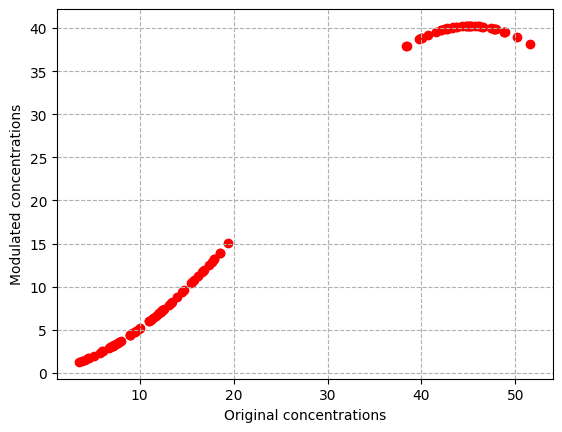

In [286]:
def modulate_y(y_target):
    y = np.asarray(y_target)
    y_norm = (y - y.min()) / (y.max() - y.min())  # normalize y to [0,1]
    center = 0.65
    coeffs = np.exp(-0.5 * ((y_norm - center) /0.45)**2)
    y_modulated = y*coeffs
    return(y_modulated)

plt.scatter(y, modulate_y(y), color = 'red')
plt.xlabel('Original concentrations')
plt.ylabel('Modulated concentrations')
plt.grid(linestyle='--')
plt.show()


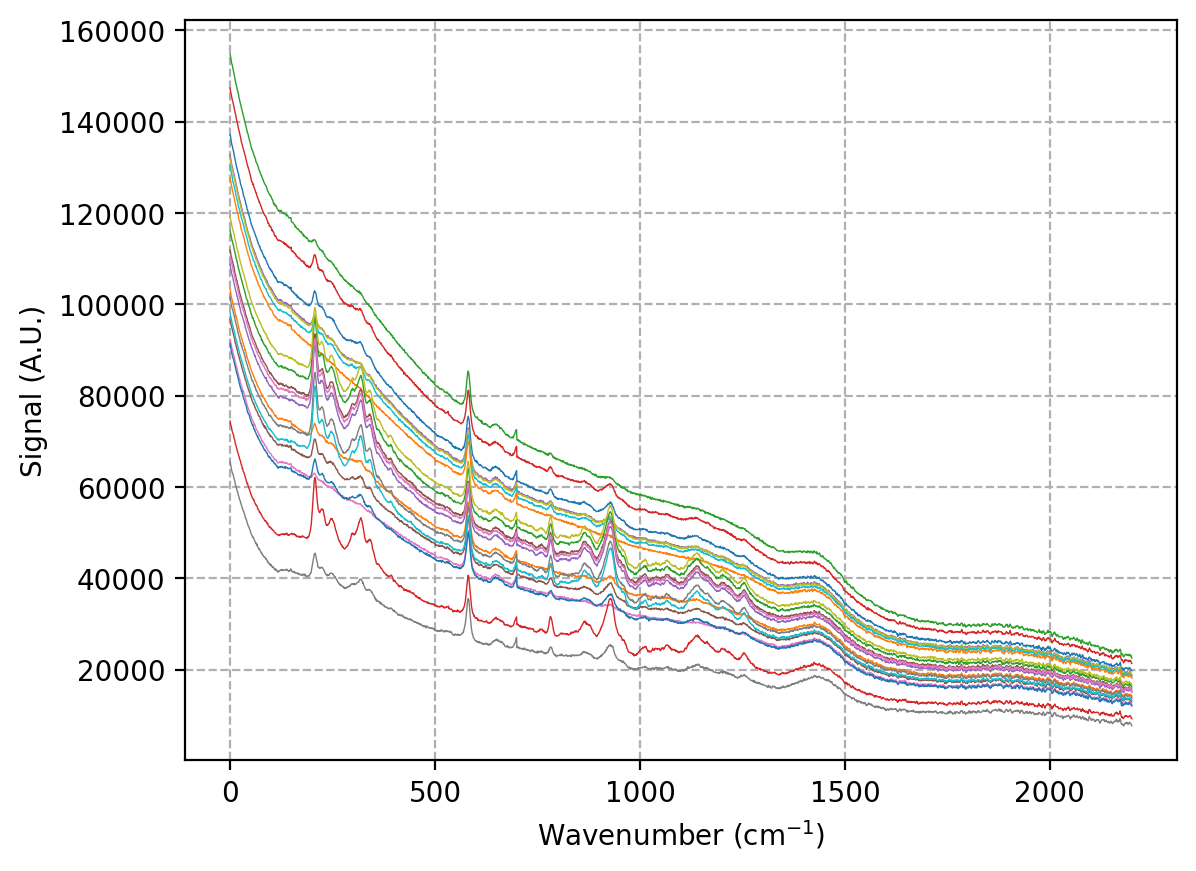

In [317]:
n_samples = 1000
original_spectrum = pd.read_csv('original_spectrum.csv', index_col=0).values

def generate_concentrations(n_samples):
    np.random.seed(0)
    
    y = np.array([np.random.randint(5,20) for _ in range(int(0.6*n_samples))] + [np.random.randint(40,50) for _ in range(int(0.4*n_samples))])
    return(y)

def generate_spectra(original_spectrum, n_samples):
    #Selecting raman bands that will be the footprint of the target analyte
    target_raman_band_1 = [x for x in range(150,500)]
    target_raman_band_2 = [x for x in range(700,1300)]

    #generating the concentrations of the target analyte
    y = generate_concentrations(n_samples)

    #initializing spectra and baselines
    pure_spectra = np.ones((original_spectrum.shape[0], n_samples))
    baseline = np.zeros((original_spectrum.shape[0], n_samples))

    #extracting baseline from a sampled experimental spectrum
    baseline_fitter = Baseline(x_data=[x for x in range(original_spectrum.shape[0])])
    background, params = baseline_fitter.asls(original_spectrum[:,0], lam=1e7, p=0.02)

    #initializing the pure spectra as the original spectrum baseline corrected
    pure_spectra = pure_spectra * (original_spectrum - background.reshape(-1,1))

    

    #multiplying the pure spectra by y on the target raman bands only with a smoothing factor
    width = 150
    scale = 0.05
    n_outliers = int(0.02*n_samples)
    outliers_index = np.random.randint(0,n_samples, n_outliers)
    y_modulated = modulate_y(y)
    y_modulated[outliers_index] = np.random.randint(1,50)
    
    
    pure_spectra[target_raman_band_1, :] = pure_spectra[target_raman_band_1, :] * scale*(1 + (y_modulated-1) * np.exp(-0.5 * ((target_raman_band_1 - np.median(target_raman_band_1))/width)**2).reshape(-1,1))
    pure_spectra[target_raman_band_2, :] = pure_spectra[target_raman_band_2, :] * scale*(1+ (y_modulated-1) * np.exp(-0.5 * ((target_raman_band_2 - np.median(target_raman_band_2))/width)**2).reshape(-1,1))

    #generating a random variation of the original baseline + noise for each spectrum
    baseline = baseline + background.reshape(-1,1) * np.random.normal(loc = 3, scale=0.9, size=(n_samples))
    noise = np.random.normal(loc = 0, scale=100, size=(original_spectrum.shape[0], n_samples))

    #generating the spectra by summing the pure spectra, the baselines and the noise
    spectra = pure_spectra + baseline + noise
    
    
    return(spectra.T, y)


X, y = generate_spectra(original_spectrum, n_samples) 
y = y + np.random.normal(loc = 0, scale = 2, size = (n_samples))

plt.figure(dpi=200)
for i in range(0,X.shape[0],50):
    plt.plot(X[i,:], lw=0.5)
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Signal (A.U.)')

plt.grid(linestyle=('--'))
plt.show()



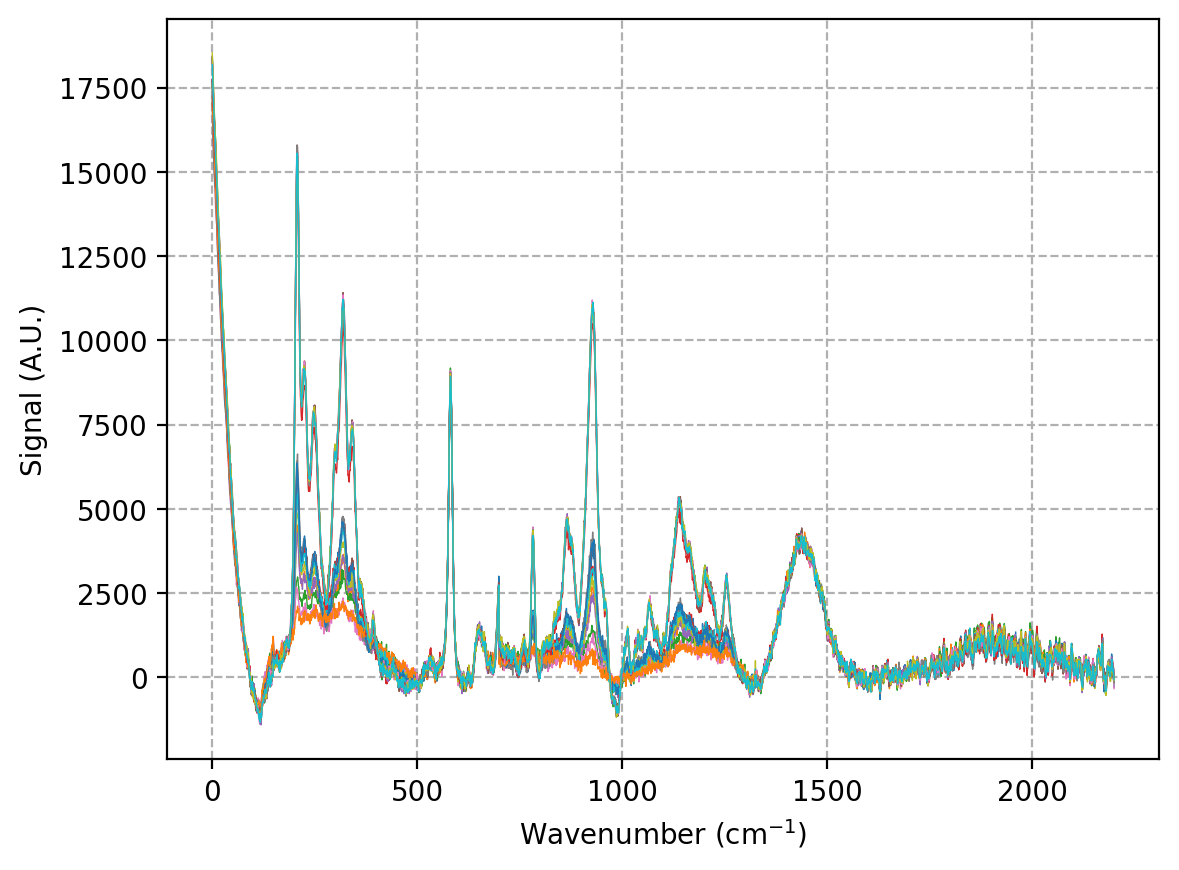

In [319]:
for i in range(X.shape[0]):
    X[i,:] = baseline_correction(X[i,:])

plt.figure(dpi=200)
for i in range(0,X.shape[0],50):
    plt.plot(X[i,:], lw=0.5)
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Signal (A.U.)')

plt.grid(linestyle=('--'))
plt.show()

# Models and benchmark

In [311]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from kennard_stone import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning) #To disable warnings from Kennard Stone train_test_split which uses deprecated functions

In [312]:
def SNV(X):
    X_scaled = (X - np.mean(X, axis = 0))/np.std(X, axis = 0)
    return(X_scaled)

def reduction(X):
    X_scaled = X/np.std(X, axis = 0)
    return(X_scaled)

def centering(X):
    X_scaled = (X - np.mean(X, axis = 0))
    return(X_scaled)

In [333]:
def benchmark_models(X,y):
    plsr = PLSRegression()
    svr = SVR()
    
    # Define hyperparameter grid
    param_grid_pls = {
        'n_components': [n for n in range(2,15)]
    }
    
    param_grid_svr = {
        'kernel': ['rbf'],
        'C': [0.01,0.1,10],
        'gamma': [1e-5,1e-4,1e-3,1e-2,1e-1,1,10]
    }
    
    datasets = [SNV(X), reduction(X), centering(X)]
    normalization = ['SNV', 'Reduction', 'Centering']
    
    best_rmse = np.inf
    c= 0
    for X_scaled in datasets:
        X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, test_size = 0.3, n_jobs = -1)
        pls_gs = GridSearchCV(plsr, param_grid_pls, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
        pls_gs.fit(X_train, y_train)
        y_pred = pls_gs.best_estimator_.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if rmse<best_rmse:
            best_norm = normalization[c]
            best_rmse = rmse
            best_parameters = pls_gs.best_params_
            best_r2 = r2_score(y_pred, y_test)
        c+=1
    
    print(f'PLS - Best RMSE: {best_rmse}')
    print(f'Best parameters: {best_parameters}')
    print(f'Best normalization: {best_norm}')
    print(f'Best R²: {best_r2}')
    print('---------------------------------------')
    
    
    best_rmse = np.inf
    c= 0
    for X_scaled in datasets:
        X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, test_size = 0.3, n_jobs = -1)
        svr_gs = GridSearchCV(svr, param_grid_svr, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
        svr_gs.fit(X_train, y_train)
        y_pred = svr_gs.best_estimator_.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if rmse<best_rmse:
            best_norm =  normalization[c]
            best_rmse = rmse
            best_parameters = svr_gs.best_params_
            best_r2 = r2_score(y_pred, y_test)
        c+=1
    
    print(f'SVR - Best RMSE: {best_rmse}')
    print(f'Best parameters: {best_parameters}')
    print(f'Best normalization: {best_norm}')
    print(f'Best R²: {best_r2}')
    print('---------------------------------------')
    
    best_rmse = np.inf
    c= 0
    for X_scaled in datasets:
        X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, test_size = 0.3, n_jobs = -1)
        pls_gs = GridSearchCV(plsr, param_grid_pls, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
        pls_gs.fit(X_train, y_train)
    
        X_train_transform, X_test_transform = pls_gs.best_estimator_.transform(X_train), pls_gs.best_estimator_.transform(X_test)
        
        pls_svr_gs = GridSearchCV(svr, param_grid_svr, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
        pls_svr_gs.fit(X_train_transform, y_train)
        y_pred = pls_svr_gs.best_estimator_.predict(X_test_transform)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if rmse<best_rmse:
            best_norm =  normalization[c]
            best_rmse = rmse
            best_parameters = pls_svr_gs.best_params_, pls_gs.best_params_
            best_r2 = r2_score(y_pred, y_test)
        c+=1
    
    print(f'PLS- SVR - Best RMSE: {best_rmse}')
    print(f'Best parameters: {best_parameters}')
    print(f'Best normalization: {best_norm}')
    print(f'Best R²: {best_r2}')

    return()

process_samples = np.random.randint(0, X.shape[0], int(0.8*n_samples))
training_samples = [x for x in range(X.shape[0]) if x not in process_samples]


X_process = X[process_samples]
X_training = X[training_samples]
y_process = y[process_samples]
y_training = y[training_samples]

benchmark_models(X_training, y_training)

PLS - Best RMSE: 6.118236798699138
Best parameters: {'n_components': 2}
Best normalization: SNV
Best R²: 0.856482632352094
---------------------------------------
SVR - Best RMSE: 4.8102943498596815
Best parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Best normalization: SNV
Best R²: 0.9145215565077762
---------------------------------------
PLS- SVR - Best RMSE: 4.232043090293933
Best parameters: ({'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}, {'n_components': 2})
Best normalization: Centering
Best R²: 0.9363275199684543


()

### Modeling

In [334]:
def model(X, y):
    plsr = PLSRegression()
    svr = SVR()
    
    # Define hyperparameter grid
    param_grid_pls = {
        'n_components': [n for n in range(2,15)]
    }
    
    param_grid_svr = {
        'kernel': ['rbf'],
        'C': [0.01,0.1,10],
        'gamma': [1e-5,1e-4,1e-3,1e-2,1e-1,1,10]
    }
    
    datasets = [SNV(X), reduction(X), centering(X)]
    normalization = ['SNV', 'Reduction', 'Centering']
    best_rmse = np.inf
    c= 0
    for X_scaled in datasets:
        X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, test_size = 0.3, n_jobs = -1)
        pls_gs = GridSearchCV(plsr, param_grid_pls, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
        pls_gs.fit(X_train, y_train)
    
        X_train_transform, X_test_transform = pls_gs.best_estimator_.transform(X_train), pls_gs.best_estimator_.transform(X_test)
        
        pls_svr_gs = GridSearchCV(svr, param_grid_svr, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
        pls_svr_gs.fit(X_train_transform, y_train)
        y_pred = pls_svr_gs.best_estimator_.predict(X_test_transform)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        if rmse<best_rmse:
            best_norm =  normalization[c]
            best_rmse = rmse

        c+=1
    print(best_rmse)
    return(pls_gs.best_estimator_, pls_svr_gs.best_estimator_, best_norm)

pls, svr, norm = model(X_training, y_training)

4.232043090293933


### Process monitoring

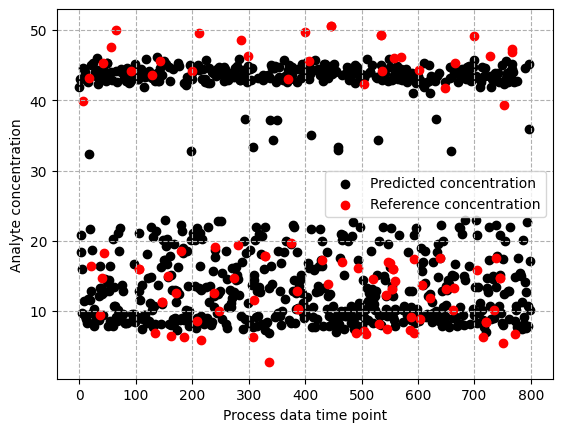

In [335]:
def monitoring(X, y, pls, svr, norm):
    datasets = [SNV(X), reduction(X), centering(X)]
    normalization = ['SNV', 'Reduction', 'Centering']
    X_scaled = datasets[normalization.index(norm)]

    y_pred = svr.predict(pls.transform(X_scaled))

    return(y_pred)

process_ref_idx = np.random.randint(0,len(y_process), 100)
plt.scatter([x for x in range(len(y_process))], monitoring(X_process, y_process, pls, svr, norm), color = 'black', label= 'Predicted concentration')
plt.scatter(process_ref_idx, y_process[process_ref_idx], color = 'red', label='Reference concentration')
plt.xlabel('Process data time point')
plt.ylabel('Analyte concentration')
plt.grid(linestyle=('--'))
plt.legend()
plt.show()

### Learning curve

In [336]:
from tqdm import tqdm
import scipy

In [338]:
def generate_learning_curve(X,y, repetitions=15):

    plsr = PLSRegression()
    svr = SVR()
    
    param_grid_pls = {
        'n_components': [n for n in range(2,11)]
    }

    param_grid_svr = {
        'kernel': ['rbf'],
        'C': [0.01,0.1,10],
        'gamma': [1e-5,1e-4,1e-3,1e-2,1e-1,1,10]
    }
    
    score = np.zeros((repetitions,X.shape[0]-20))
    for repetition in tqdm(range(repetitions)):
        
        X_copy = X.copy()
        y_copy = y.copy()
        for deletion in range(X.shape[0]-20):
            del_idx = np.random.randint(0,X_copy.shape[0])
            X_copy = np.delete(X_copy, del_idx, axis=0)
            y_copy = np.delete(y_copy, del_idx, axis=0)
            
            X_scaled = SNV(X_copy)
            pls_gs = GridSearchCV(plsr, param_grid_pls, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
            pls_gs.fit(X_train, y_train)
        
            X_train_transform, X_test_transform = pls_gs.best_estimator_.transform(X_train), pls_gs.best_estimator_.transform(X_test)
            
            pls_svr_gs = GridSearchCV(svr, param_grid_svr, scoring='neg_root_mean_squared_error',cv=5, n_jobs=-1)
            pls_svr_gs.fit(X_train_transform, y_train)
            y_pred = pls_svr_gs.best_estimator_.predict(X_test_transform)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
            score[repetition, deletion] = rmse
        mean_score = np.mean(score, axis = 0)
    
    return(score)

In [96]:
def display_learning_curve(learning_curve_scores):
    scoring = pd.DataFrame(learning_curve_scores.T)
    
    mean = scoring.mean(axis=1)
    stddev = scoring.std(axis=1)
    
    
    confidence = 0.95
    n = scoring.shape[1]  # Assuming the number of samples is the number of columns in 'scoring'
    t_value = scipy.stats.t.ppf((1 + confidence) / 2.0, df=n - 1)
    margin_of_error = t_value * (stddev / np.sqrt(n))
    ci_lower = mean - margin_of_error
    ci_upper = mean + margin_of_error
    
    x = [x for x in scoring.index]
    x.reverse()
    mean = mean.iloc[::-1]
    ci_upper = ci_upper.iloc[::-1]
    ci_lower = ci_lower.iloc[::-1]
    
    def exponential_func(x, a, b, c):
        return a * np.exp(-b * np.array(x)) + c
    
    # popt, pcov = scipy.optimize.curve_fit(exponential_func, x[1:], mean[1:])
    # a, b, c = popt
    
    # Find the point where the curve starts to become flat
    threshold = 0.1  # Adjust this value as needed
    flat_point = np.argmax(np.abs(np.diff(exponential_func(x, a, b, c))) < threshold)
    flat_x = int(x[flat_point])
    flat_y = exponential_func(flat_x, a, b, c)
    
    # plt.scatter(x, mean, color='black', label='Mean RMSEP')
    plt.plot(x, mean, color='red', label='Mean RMSEP')
    
    #plt.plot(x, exponential_func(x, a, b, c), color='blue', label='Exponential Fit', linestyle='--')
    
    plt.scatter(flat_x, flat_y, color='purple', marker='x', s=200, label='Saturation Point')
    
    plt.fill_between(x, ci_lower, ci_upper, color='red', alpha=0.2, lw=0.5, linestyle='--', label='Confidence Interval (95%)')
    
    plt.xlabel('Number of observations')
    
    
    plt.ylabel('RMSEP (g/L)')
    plt.legend()
    plt.grid(linestyle='--', linewidth=0.5)
    
    plt.xticks([point for point in range(0,np.max(x),10)])  # Set the x-axis lower limit to 0, upper limit is automatic
    plt.ylim(0, None)
    
    plt.tight_layout()
    plt.show()

    return()